In [1]:
from jarvis.db.figshare import data
dft_3d = data("dft_3d")

Obtaining 3D dataset 76k ...
Reference:https://www.nature.com/articles/s41524-020-00440-1
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.


In [2]:
from jarvis.core.atoms import Atoms
from pymatgen.core import Structure
from pymatgen.core.lattice import Lattice
from collections import Counter
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np


In [3]:
# Lenght of the Dataset
len(dft_3d)

75993

In [4]:
#TC_SUPERCON    
tc_ = []
for i in dft_3d:
    if i["Tc_supercon"] != "na":
        atoms = Atoms.from_dict(i["atoms"])
        info = {}
        info["formula"] = atoms.composition.reduced_formula
        info["prop"] = round(i["Tc_supercon"], 3)
        info["lengths"] = atoms.lattice.abc
        info["angles"] = atoms.lattice.angles
        info["atom_ids"] = atoms.elements
        info["frac_coords"] = atoms.frac_coords
        tc_.append(info)

#optb88vdw_bandgap    
opt_ = []
for i in dft_3d:
    if i["optb88vdw_bandgap"] > 0.0:
        atoms = Atoms.from_dict(i["atoms"])
        info = {}
        info["formula"] = atoms.composition.reduced_formula
        info["prop"] = round(i["optb88vdw_bandgap"], 3)
        info["lengths"] = atoms.lattice.abc
        info["angles"] = atoms.lattice.angles
        info["atom_ids"] = atoms.elements
        info["frac_coords"] = atoms.frac_coords
        opt_.append(info)

#mbj_bandgap    
mbj_ = []
for i in dft_3d:
    if i["mbj_bandgap"] != "na" :
        atoms = Atoms.from_dict(i["atoms"])
        info = {}
        info["formula"] = atoms.composition.reduced_formula
        info["prop"] = round(i["mbj_bandgap"], 3)
        info["lengths"] = atoms.lattice.abc
        info["angles"] = atoms.lattice.angles
        info["atom_ids"] = atoms.elements
        info["frac_coords"] = atoms.frac_coords
        mbj_.append(info)

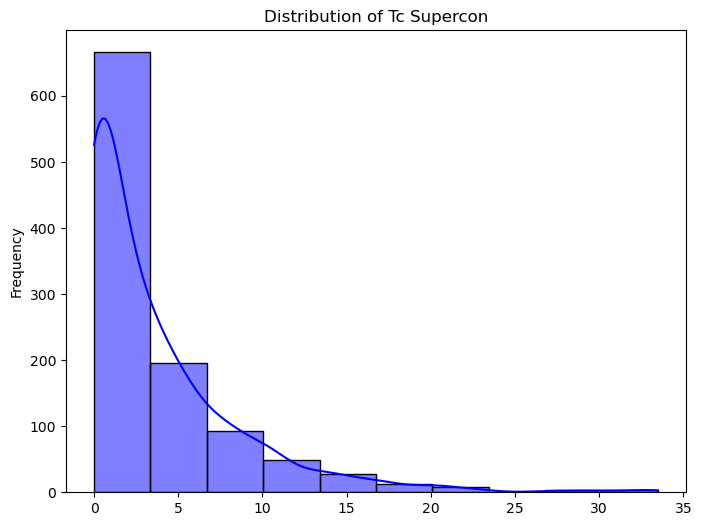

In [ ]:
import seaborn as sns
values = [item.get("prop") for item in tc_]
plt.figure(figsize=(8, 6))
# Load dataset
# Set style and context
#sns.set_style("whitegrid")

sns.histplot(values, bins=10, kde=True, color='blue')
plt.title(f'Distribution of Tc Supercon') #, fontsize=14)
plt.ylabel('Frequency') #, fontsize=14)
#.grid(axis='x', linestyle='--', alpha=0.5)
#plt.tight_layout()
plt.show()

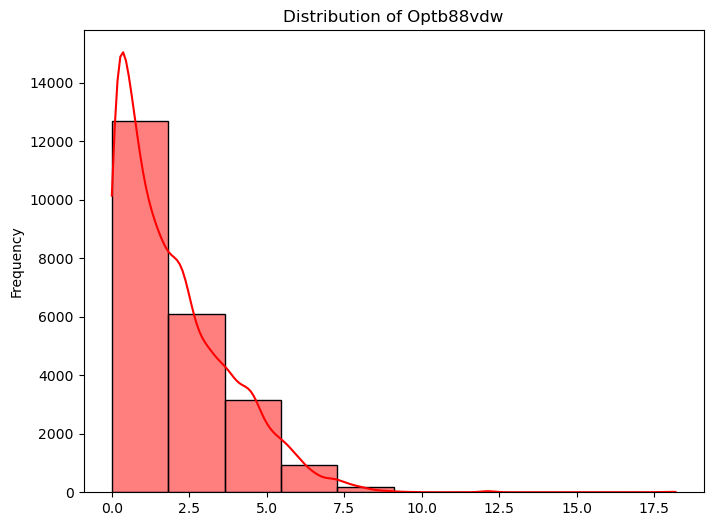

In [14]:
# Draw Property Value Distribtuion

import seaborn as sns
values = [item.get("prop") for item in opt_]
plt.figure(figsize=(8, 6))
# Load dataset
# Set style and context
#sns.set_style("whitegrid")

sns.histplot(values, bins=10, kde=True, color='red')
plt.title(f'Distribution of Optb88vdw') #, fontsize=14)
plt.ylabel('Frequency') #, fontsize=14)
#.grid(axis='x', linestyle='--', alpha=0.5)
#plt.tight_layout()
plt.show()

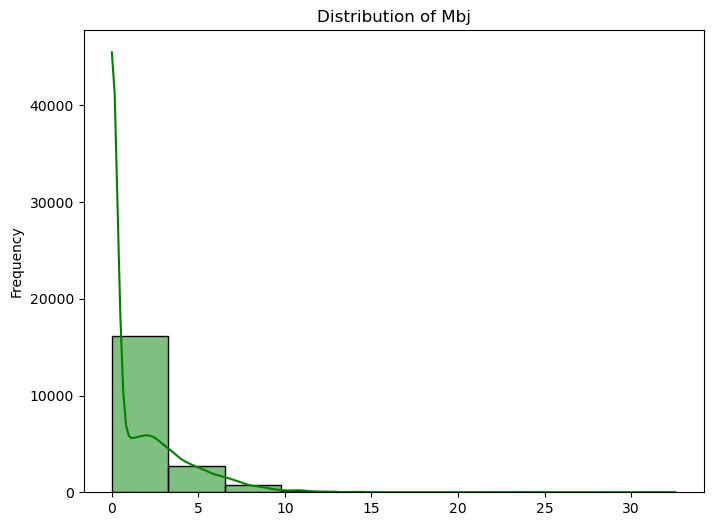

In [18]:
# Draw Property Value Distribtuion

import seaborn as sns
values = [item.get("prop") for item in mbj_]
plt.figure(figsize=(8, 6))
# Load dataset
# Set style and context
#sns.set_style("whitegrid")

sns.histplot(values, bins=10, kde=True, color='green')
plt.title(f'Distribution of Mbj') #, fontsize=14)
plt.ylabel('Frequency') #, fontsize=14)
#.grid(axis='x', linestyle='--', alpha=0.5)
#plt.tight_layout()
plt.show()

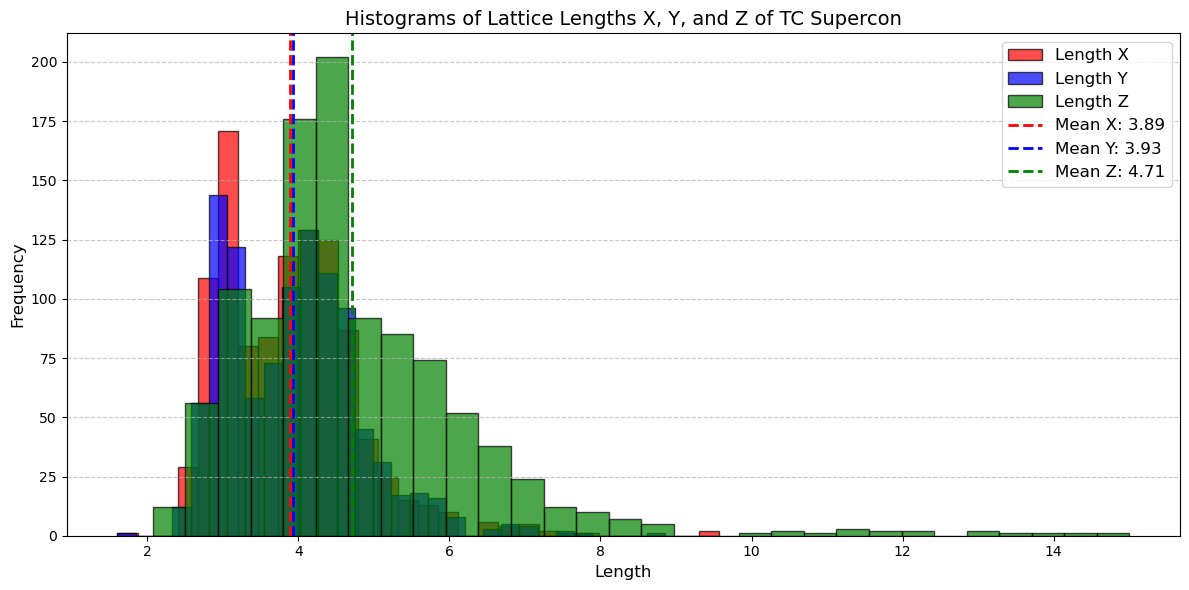

In [130]:
# Plot histograms for x, y, z
plt.figure(figsize=(12, 6))

plt.hist([x["lengths"][0] for x in tc_], bins=30, alpha=0.7, label='Length X', color='red', edgecolor='black')
plt.hist([x["lengths"][1] for x in tc_], bins=30, alpha=0.7, label='Length Y', color='blue', edgecolor='black')
plt.hist([x["lengths"][2] for x in tc_], bins=30, alpha=0.7, label='Length Z', color='green', edgecolor='black')

mean_x = np.mean([x["lengths"][0] for x in tc_])
mean_y = np.mean([x["lengths"][1] for x in tc_])
mean_z = np.mean([x["lengths"][2] for x in tc_])

# Add mean values as vertical lines
plt.axvline(mean_x, color='red', linestyle='--', linewidth=2, label=f'Mean X: {mean_x:.2f}')
plt.axvline(mean_y, color='blue', linestyle='--', linewidth=2, label=f'Mean Y: {mean_y:.2f}')
plt.axvline(mean_z, color='green', linestyle='--', linewidth=2, label=f'Mean Z: {mean_z:.2f}')


plt.title('Histograms of Lattice Lengths X, Y, and Z of TC Supercon', fontsize=14)
plt.xlabel('Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

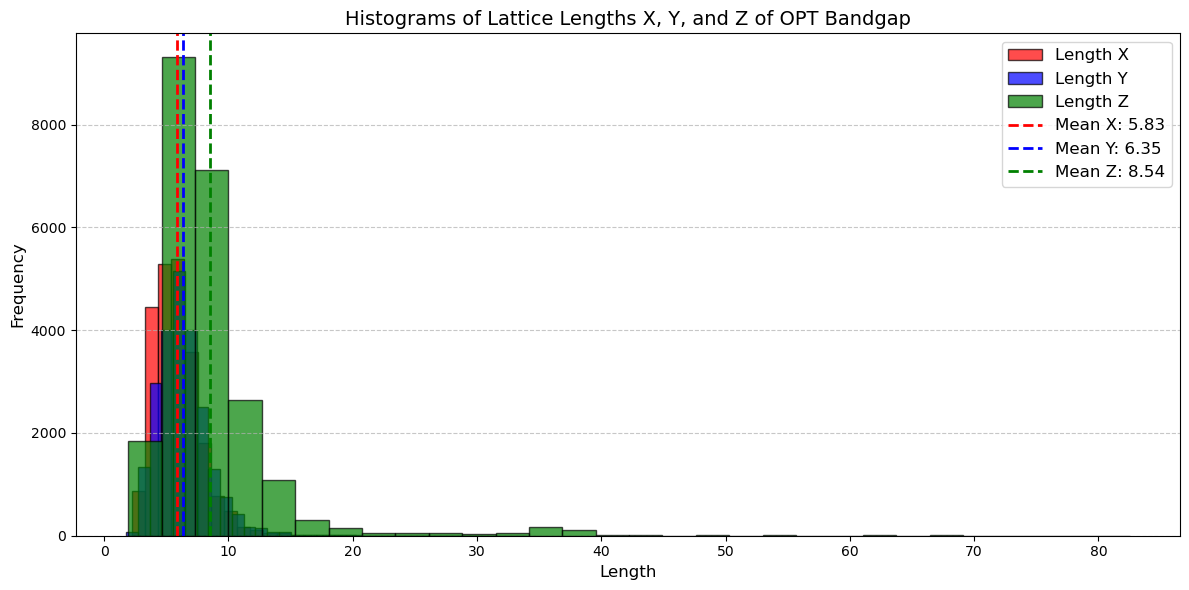

In [131]:
# Plot histograms for x, y, z
plt.figure(figsize=(12, 6))

plt.hist([x["lengths"][0] for x in opt_], bins=30, alpha=0.7, label='Length X', color='red', edgecolor='black')
plt.hist([x["lengths"][1] for x in opt_], bins=30, alpha=0.7, label='Length Y', color='blue', edgecolor='black')
plt.hist([x["lengths"][2] for x in opt_], bins=30, alpha=0.7, label='Length Z', color='green', edgecolor='black')

mean_x = np.mean([x["lengths"][0] for x in opt_])
mean_y = np.mean([x["lengths"][1] for x in opt_])
mean_z = np.mean([x["lengths"][2] for x in opt_])

# Add mean values as vertical lines
plt.axvline(mean_x, color='red', linestyle='--', linewidth=2, label=f'Mean X: {mean_x:.2f}')
plt.axvline(mean_y, color='blue', linestyle='--', linewidth=2, label=f'Mean Y: {mean_y:.2f}')
plt.axvline(mean_z, color='green', linestyle='--', linewidth=2, label=f'Mean Z: {mean_z:.2f}')


plt.title('Histograms of Lattice Lengths X, Y, and Z of OPT Bandgap', fontsize=14)
plt.xlabel('Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

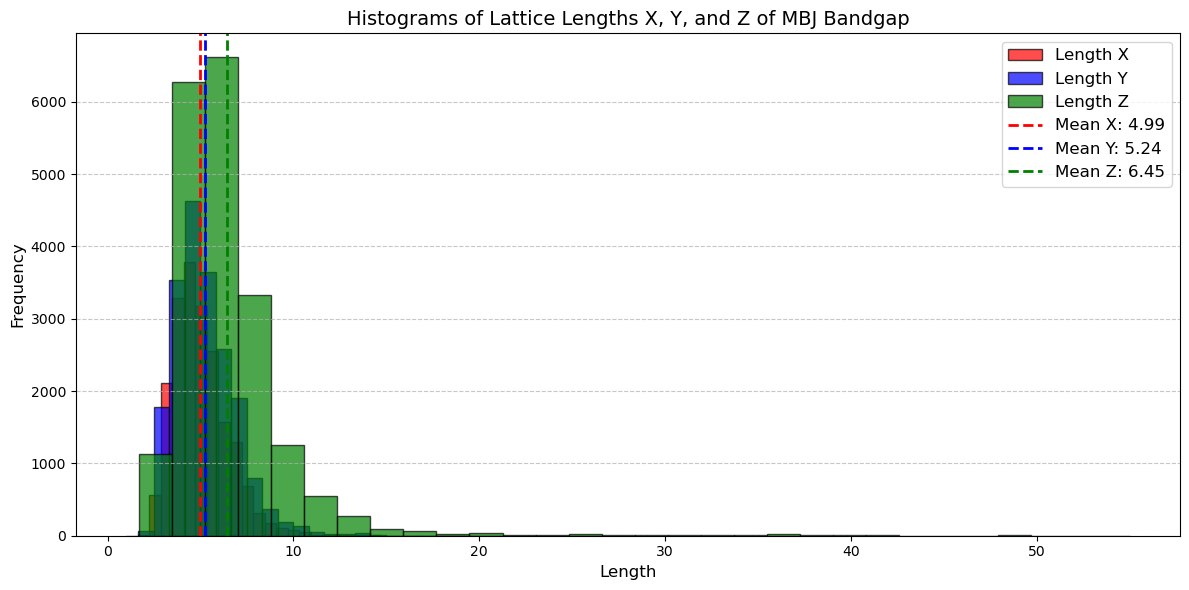

In [132]:
# Plot histograms for x, y, z
plt.figure(figsize=(12, 6))

plt.hist([x["lengths"][0] for x in mbj_], bins=30, alpha=0.7, label='Length X', color='red', edgecolor='black')
plt.hist([x["lengths"][1] for x in mbj_], bins=30, alpha=0.7, label='Length Y', color='blue', edgecolor='black')
plt.hist([x["lengths"][2] for x in mbj_], bins=30, alpha=0.7, label='Length Z', color='green', edgecolor='black')

mean_x = np.mean([x["lengths"][0] for x in mbj_])
mean_y = np.mean([x["lengths"][1] for x in mbj_])
mean_z = np.mean([x["lengths"][2] for x in mbj_])

# Add mean values as vertical lines
plt.axvline(mean_x, color='red', linestyle='--', linewidth=2, label=f'Mean X: {mean_x:.2f}')
plt.axvline(mean_y, color='blue', linestyle='--', linewidth=2, label=f'Mean Y: {mean_y:.2f}')
plt.axvline(mean_z, color='green', linestyle='--', linewidth=2, label=f'Mean Z: {mean_z:.2f}')


plt.title('Histograms of Lattice Lengths X, Y, and Z of MBJ Bandgap', fontsize=14)
plt.xlabel('Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

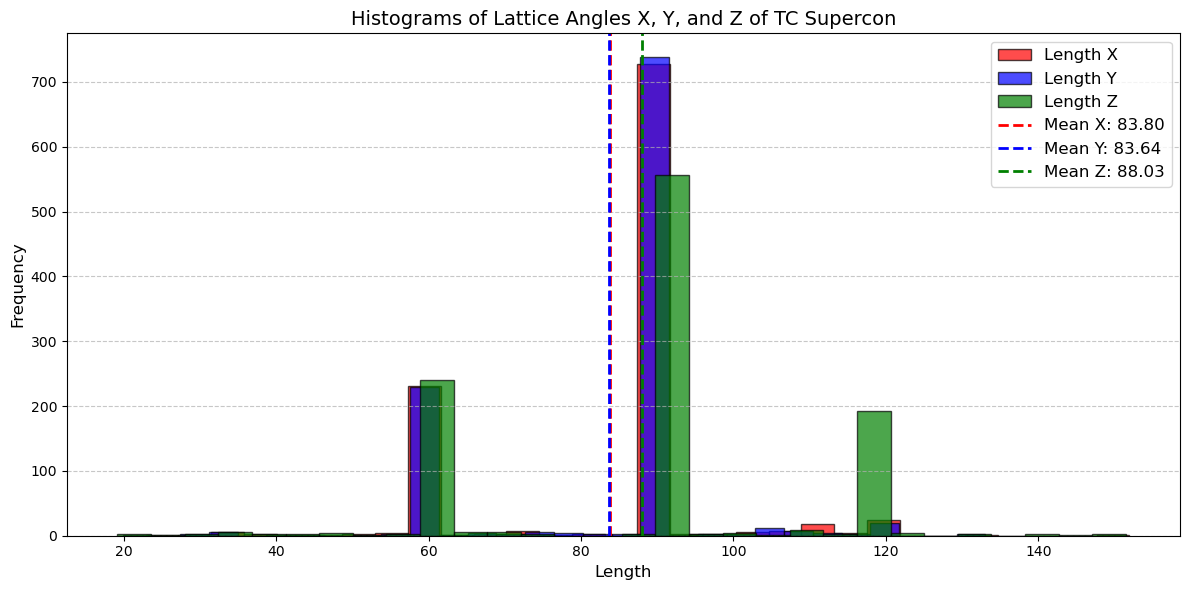

In [133]:
# Plot histograms for x, y, z
plt.figure(figsize=(12, 6))

plt.hist([x["angles"][0] for x in tc_], bins=30, alpha=0.7, label='Length X', color='red', edgecolor='black')
plt.hist([x["angles"][1] for x in tc_], bins=30, alpha=0.7, label='Length Y', color='blue', edgecolor='black')
plt.hist([x["angles"][2] for x in tc_], bins=30, alpha=0.7, label='Length Z', color='green', edgecolor='black')

mean_x = np.mean([x["angles"][0] for x in tc_])
mean_y = np.mean([x["angles"][1] for x in tc_])
mean_z = np.mean([x["angles"][2] for x in tc_])

# Add mean values as vertical lines
plt.axvline(mean_x, color='red', linestyle='--', linewidth=2, label=f'Mean X: {mean_x:.2f}')
plt.axvline(mean_y, color='blue', linestyle='--', linewidth=2, label=f'Mean Y: {mean_y:.2f}')
plt.axvline(mean_z, color='green', linestyle='--', linewidth=2, label=f'Mean Z: {mean_z:.2f}')


plt.title('Histograms of Lattice Angles X, Y, and Z of TC Supercon', fontsize=14)
plt.xlabel('Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

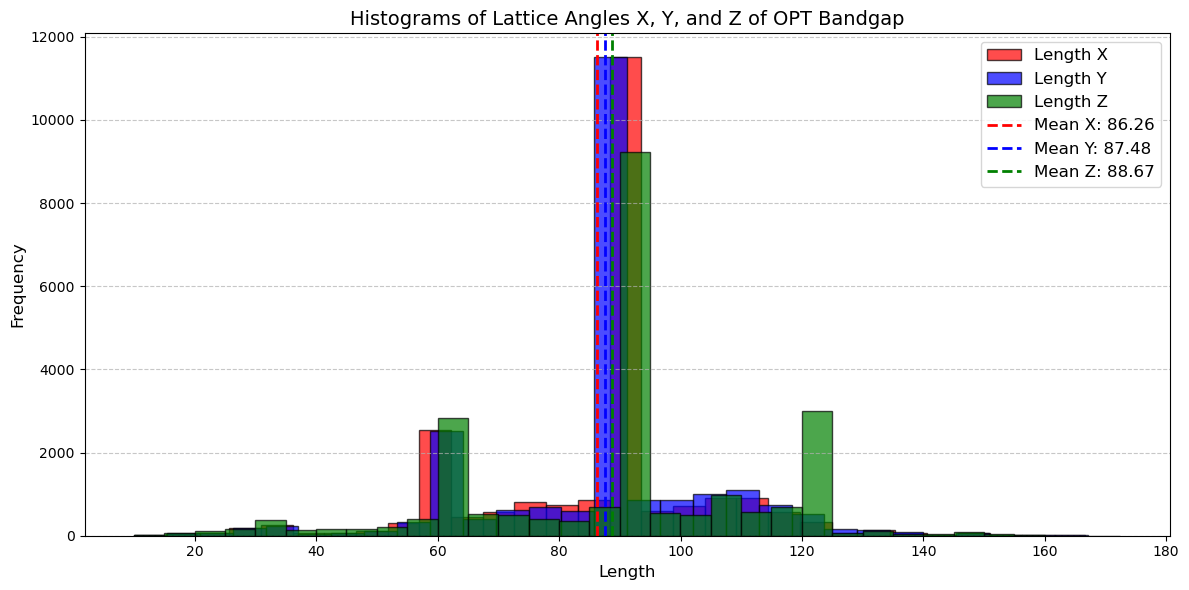

In [134]:
# Plot histograms for x, y, z
plt.figure(figsize=(12, 6))

plt.hist([x["angles"][0] for x in opt_], bins=30, alpha=0.7, label='Length X', color='red', edgecolor='black')
plt.hist([x["angles"][1] for x in opt_], bins=30, alpha=0.7, label='Length Y', color='blue', edgecolor='black')
plt.hist([x["angles"][2] for x in opt_], bins=30, alpha=0.7, label='Length Z', color='green', edgecolor='black')

mean_x = np.mean([x["angles"][0] for x in opt_])
mean_y = np.mean([x["angles"][1] for x in opt_])
mean_z = np.mean([x["angles"][2] for x in opt_])

# Add mean values as vertical lines
plt.axvline(mean_x, color='red', linestyle='--', linewidth=2, label=f'Mean X: {mean_x:.2f}')
plt.axvline(mean_y, color='blue', linestyle='--', linewidth=2, label=f'Mean Y: {mean_y:.2f}')
plt.axvline(mean_z, color='green', linestyle='--', linewidth=2, label=f'Mean Z: {mean_z:.2f}')


plt.title('Histograms of Lattice Angles X, Y, and Z of OPT Bandgap', fontsize=14)
plt.xlabel('Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

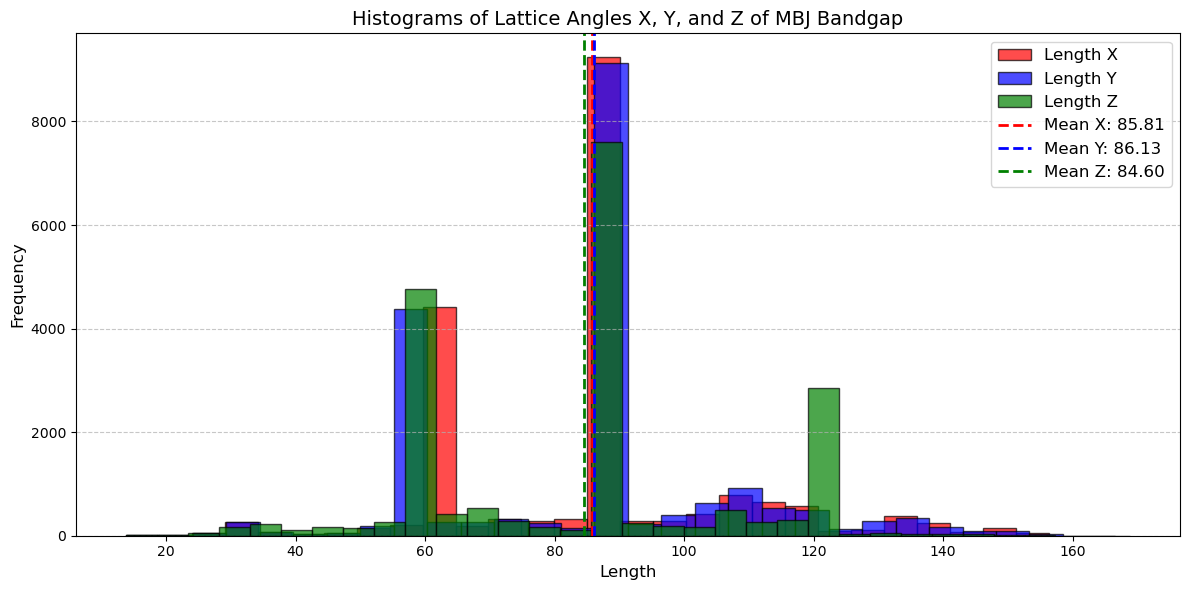

In [135]:
# Plot histograms for x, y, z
plt.figure(figsize=(12, 6))

plt.hist([x["angles"][0] for x in mbj_], bins=30, alpha=0.7, label='Length X', color='red', edgecolor='black')
plt.hist([x["angles"][1] for x in mbj_], bins=30, alpha=0.7, label='Length Y', color='blue', edgecolor='black')
plt.hist([x["angles"][2] for x in mbj_], bins=30, alpha=0.7, label='Length Z', color='green', edgecolor='black')

mean_x = np.mean([x["angles"][0] for x in mbj_])
mean_y = np.mean([x["angles"][1] for x in mbj_])
mean_z = np.mean([x["angles"][2] for x in mbj_])

# Add mean values as vertical lines
plt.axvline(mean_x, color='red', linestyle='--', linewidth=2, label=f'Mean X: {mean_x:.2f}')
plt.axvline(mean_y, color='blue', linestyle='--', linewidth=2, label=f'Mean Y: {mean_y:.2f}')
plt.axvline(mean_z, color='green', linestyle='--', linewidth=2, label=f'Mean Z: {mean_z:.2f}')


plt.title('Histograms of Lattice Angles X, Y, and Z of MBJ Bandgap', fontsize=14)
plt.xlabel('Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

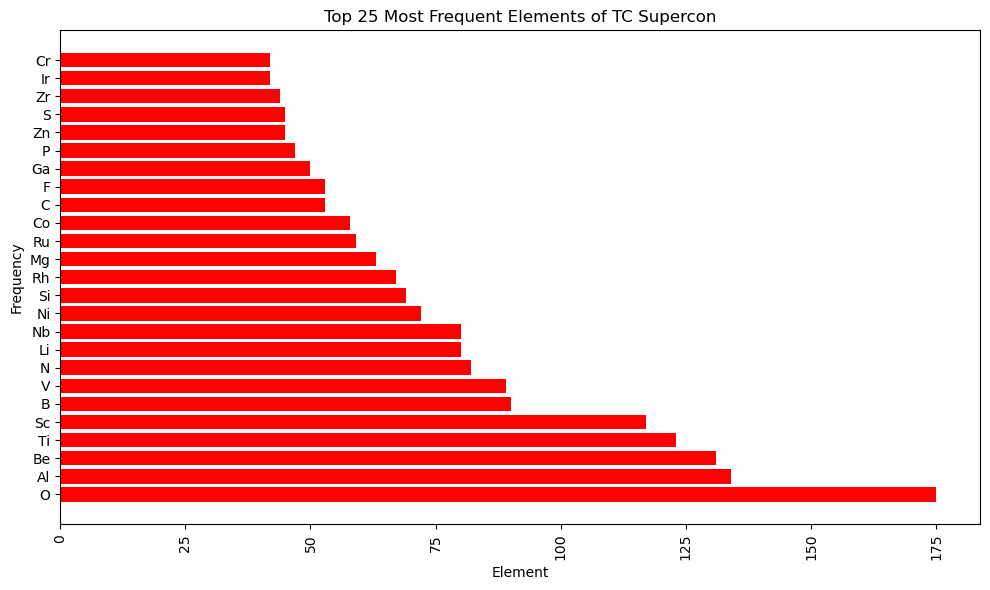

In [156]:
# Step 1: Flatten the dictionary into a single list
all_elements = []
for i in tc_:
    all_elements.extend(set(i["atom_ids"]))

element_counts = Counter(all_elements)

# Step 3: Get the top 25 most common elements
top_25 = element_counts.most_common(25)

# Step 4: Prepare the data for plotting
labels, counts = zip(*top_25)

# Step 5: Plot the results
plt.figure(figsize=(10, 6))
plt.barh(labels, counts, color='red')
plt.xlabel('Element')
plt.ylabel('Frequency')
plt.title('Top 25 Most Frequent Elements of TC Supercon')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


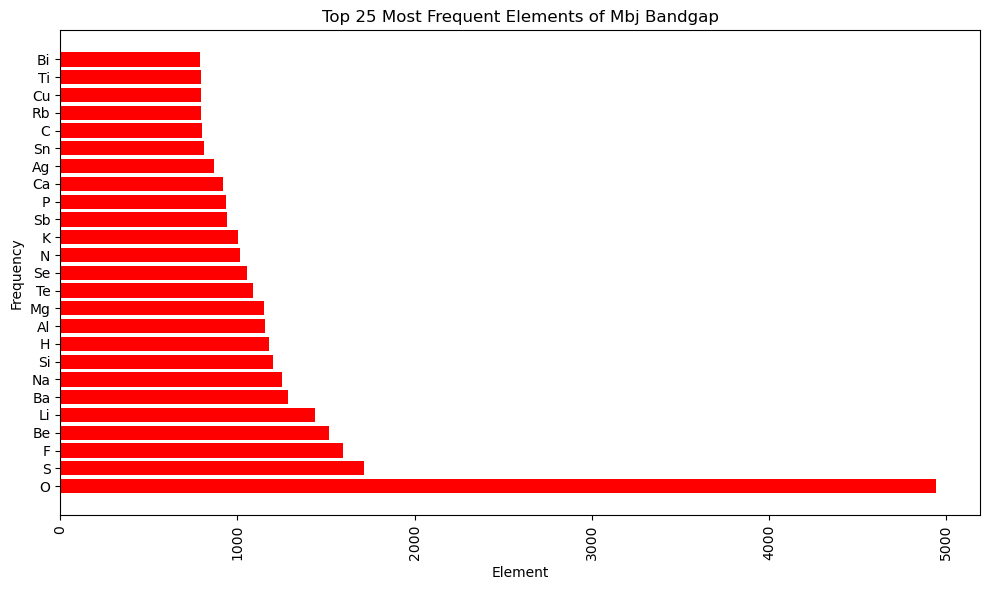

In [157]:
# Step 1: Flatten the dictionary into a single list
all_elements = []
for i in mbj_:
    all_elements.extend(set(i["atom_ids"]))

element_counts = Counter(all_elements)

# Step 3: Get the top 25 most common elements
top_25 = element_counts.most_common(25)

# Step 4: Prepare the data for plotting
labels, counts = zip(*top_25)

# Step 5: Plot the results
plt.figure(figsize=(10, 6))
plt.barh(labels, counts, color='red')
plt.xlabel('Element')
plt.ylabel('Frequency')
plt.title('Top 25 Most Frequent Elements of Mbj Bandgap')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


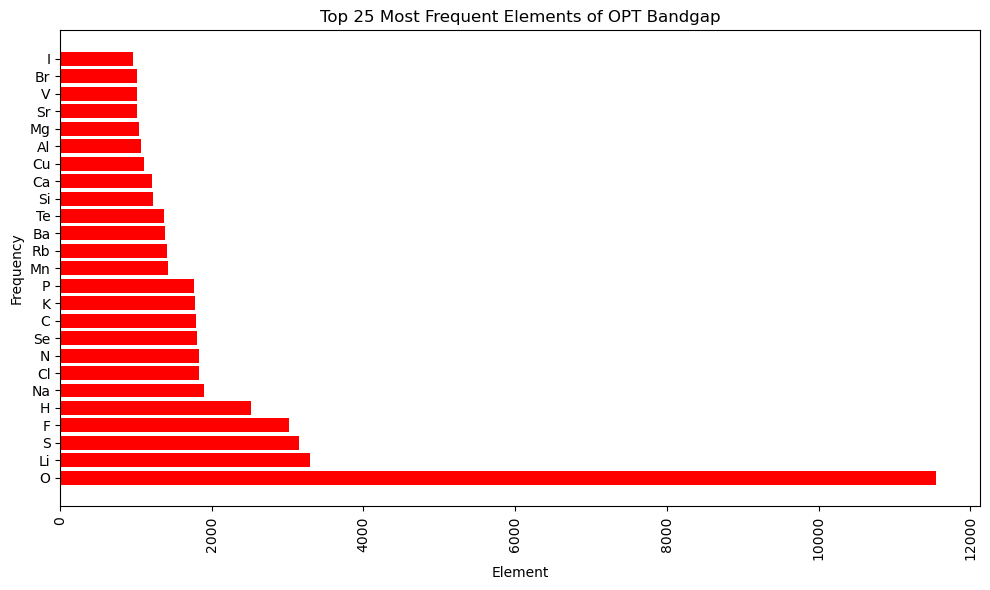

In [158]:
# Step 1: Flatten the dictionary into a single list
all_elements = []
for i in opt_:
    all_elements.extend(set(i["atom_ids"]))

element_counts = Counter(all_elements)

# Step 3: Get the top 25 most common elements
top_25 = element_counts.most_common(25)

# Step 4: Prepare the data for plotting
labels, counts = zip(*top_25)

# Step 5: Plot the results
plt.figure(figsize=(10, 6))
plt.barh(labels, counts, color='red')
plt.xlabel('Element')
plt.ylabel('Frequency')
plt.title('Top 25 Most Frequent Elements of OPT Bandgap')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
